## Introduction

The [ZymoBIOMICS mock microbial community](https://github.com/LomanLab/mockcommunity) is a standardized mixture of known bacterial and fungal taxa at defined proportions. Because the true composition is known, it is widely used as a benchmarking and proof-of-concept dataset for evaluating bioinformatics pipelines, feature representations, and ecological analysis methods.

In this homework, you will use the Zymo mock community as a controlled testbed to assess the quality of **GenSLMs sequence embeddings**.



### Background

GenSLMs embeddings are pretrained representations derived from the **GenSLM foundation model** (GitHub: https://github.com/ramanathanlab/genslm).  
They are intended to capture biologically meaningful patterns such as evolutionary or phylogenetic relatedness and shared functional motifs.

There are 10 reference genomes in this dataset. Metagenomic reads have been assembled into contigs. The reference genome IDs correspond to:

- **0**: *Bacillus subtilis*
- **1**: *Cryptococcus neoformans*
- **2**: *Enterococcus faecalis*
- **3**: *Escherichia coli*
- **4**: *Lactobacillus fermentum*
- **5**: *Listeria monocytogenes*
- **6**: *Pseudomonas aeruginosa*
- **7**: *Saccharomyces cerevisiae*
- **8**: *Salmonella enterica*
- **9**: *Staphylococcus aureus*

Among these genomes, **E. coli** and **Salmonella** share ~87.04% similarity, and **Bacillus** and **Staphylococcus** share ~72.25% similarity.



### Hypothesis

We hypothesize that GenSLMs embeddings encode evolutionary and functional signals strongly enough that:

1. A classifier trained on the embeddings can accurately predict contig origin (genome ID).
2. Low-dimensional projections (PCA / UMAP / t-SNE) reveal coherent clusters aligned with genome IDs, including known similarity pairs (e.g., *E. coli* vs. *Salmonella*).
3. Clustering algorithms applied to the embeddings approximate true contig origin groupings with high homogeneity and completeness.



### Strategy

1. Load contig-level embeddings and genome IDs.
2. Perform a stratified train/test split to evaluate generalization.
3. Train multiple multi-class classifiers (Logistic Regression, LightGBM, XGBoost, CatBoost) and select the best model based on macro F1.
4. To speed up classification, reduce the dimensionality using PCA and UMAP, and evaluate how different numbers of components affect classification performance.
5. Visualize the embeddings using PCA, t-SNE, and UMAP with tuned hyperparameters; annotate notable overlaps (e.g., *E. coli* vs. *Salmonella*).
6. Apply clustering (DBSCAN / HDBSCAN / KMeans) on the 2D reduced space and compute homogeneity and completeness scores.




### Evaluation

- **Classification**: macro precision, macro recall, macro F1, accuracy.
- **Visualization**: qualitative cluster separation and overlapping
- **Clustering**: homogeneity_score, completeness_score, number of clusters vs expected genomes, outlier count (if applicable).


### Open-Ended Nature

This assignment is intentionally open-ended — there is no single “correct” setting.  
You are encouraged to explore reasonable hyperparameters.  
For some steps, I also provide my own settings so that everyone starts from the same baseline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
genslm_npz = np.load("zymo_genslm_embeddings.npz")
genslm_npz['e'].shape
genslm_npz['id'].shape

(11724,)

In [3]:
genslm_embed = pd.DataFrame(genslm_npz['e'])
genslm_embed['rid'] = genslm_npz['id']
genslm_embed=genslm_embed.sample(frac=1)
genslm_embed.describe()

,0,1,2,3,4,5,6,7,8,9,...,3831,3832,3833,3834,3835,3836,3837,3838,3839,rid
count,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,...,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000
mean,-0.172946,0.229652,-0.091656,0.312128,0.221963,-0.049410,0.394963,-0.066101,0.109899,0.072875,...,0.035922,0.245670,0.310494,-0.097445,-0.038705,-0.068324,-0.027750,-0.171403,-1.567976,2.696691
std,0.107995,0.070312,0.091085,0.130253,0.260921,0.037091,0.111554,0.044227,0.169603,0.072104,...,0.045836,0.076481,0.064397,0.149072,0.061731,0.055843,0.054115,0.165558,0.234705,2.662503
min,-0.414492,-0.170474,-0.428855,-0.189030,-0.202179,-0.231486,-0.068627,-0.311310,-0.246488,-0.289764,...,-0.243446,-0.108656,-0.095644,-0.376422,-0.333230,-0.330913,-0.217874,-0.518213,-1.966708,0.000000
25%,-0.281451,0.188339,-0.169851,0.190794,-0.047185,-0.071939,0.291742,-0.092717,-0.059577,0.012137,...,0.006500,0.183361,0.254403,-0.253409,-0.074627,-0.115565,-0.069625,-0.334869,-1.811119,1.000000
50%,-0.158354,0.232108,-0.103474,0.328118,0.260320,-0.047380,0.402840,-0.067295,0.129721,0.075557,...,0.037762,0.241674,0.312618,-0.076764,-0.044577,-0.072631,-0.030407,-0.139756,-1.547125,1.000000
75%,-0.075722,0.270721,-0.017998,0.433676,0.481040,-0.026329,0.496704,-0.042365,0.272931,0.133934,...,0.065301,0.317796,0.364526,0.041555,-0.002921,-0.017938,0.012859,-0.010328,-1.341360,5.000000
max,0.226545,0.548050,0.216811,0.691828,0.913784,0.229549,0.696488,0.149715,0.717532,0.328994,...,0.212165,0.430578,0.599509,0.401128,0.167531,0.099039,0.294926,0.475211,-0.598945,9.000000


In [4]:
# show the value count of the rid
genslm_embed['rid'].value_counts()

rid
1    7210
7    1326
6     694
3     519
8     496
0     405
5     297
2     284
9     282
4     211
Name: count, dtype: int64

In [5]:
# split the data into feature and target
X = genslm_embed.iloc[:, :-1].values
y = genslm_embed.iloc[:, -1].values

# split the data into training and test set with stratify
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [6]:
# scale the data
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Task 1: Multi-Class Classification (20 points)

Apply multiple classifiers to the dataset and identify the best-performing model based on the **macro F1 score**.  
The classifiers to evaluate include: **Multinomial Logistic Regression, LightGBM, XGBoost, and CatBoost**.

Please display the performance metrics for each classifier (e.g., **accuracy, macro precision, macro recall, macro F1**) to justify your selection of the top model for the downstream tasks.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [8]:
# logistic regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_test)

log_reg_metrics = {
    "accuracy": accuracy_score(y_test, log_reg_pred),
    "precision": precision_score(y_test, log_reg_pred, average="macro"),
    "recall": recall_score(y_test, log_reg_pred, average="macro"),
    "f1_score": f1_score(y_test, log_reg_pred, average="macro")
}

In [9]:
# lightgbm
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier().fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

lgbm_metrics = {
    "accuracy": accuracy_score(y_test, lgbm_pred),
    "precision": precision_score(y_test, lgbm_pred, average="macro"),
    "recall": recall_score(y_test, lgbm_pred, average="macro"),
    "f1_score": f1_score(y_test, lgbm_pred, average="macro")
}

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.344105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 979200
[LightGBM] [Info] Number of data points in the train set: 9379, number of used features: 3840
[LightGBM] [Info] Start training from score -3.365485
[LightGBM] [Info] Start training from score -0.486148
[LightGBM] [Info] Start training from score -3.721278
[LightGBM] [Info] Start training from score -3.117950
[LightGBM] [Info] Start training from score -4.016330
[LightGBM] [Info] Start training from score -3.678168
[LightGBM] [Info] Start training from score -2.827260
[LightGBM] [Info] Start training from score -2.179261
[LightGBM] [Info] Start training from score -3.162292
[LightGBM] [Info] Start training from score -3.725693
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [10]:
# xgboost
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(objective="multi:softmax").fit(X_train, y_train)
xgb_pred = xgb_clf.predict(X_test)

xgb_metrics = {
    "accuracy": accuracy_score(y_test, xgb_pred),
    "precision": precision_score(y_test, xgb_pred, average="macro"),
    "recall": recall_score(y_test, xgb_pred, average="macro"),
    "f1_score": f1_score(y_test, xgb_pred, average="macro")
}

In [11]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(iterations=1000, loss_function='MultiClass', verbose=10).fit(X_train, y_train)
cat_pred = cat_clf.predict(X_test)

cat_metrics = {
    "accuracy": accuracy_score(y_test, cat_pred),
    "precision": precision_score(y_test, cat_pred, average="macro"),
    "recall": recall_score(y_test, cat_pred, average="macro"),
    "f1_score": f1_score(y_test, cat_pred, average="macro")
}

Learning rate set to 0.088696
0:	learn: 1.7977042	total: 2.85s	remaining: 47m 29s
10:	learn: 0.7907723	total: 40.1s	remaining: 1h 7s
20:	learn: 0.5260294	total: 1m 14s	remaining: 58m 2s
30:	learn: 0.3998345	total: 1m 48s	remaining: 56m 39s
40:	learn: 0.3373013	total: 2m 26s	remaining: 56m 57s
50:	learn: 0.3021169	total: 2m 59s	remaining: 55m 37s
60:	learn: 0.2746612	total: 3m 35s	remaining: 55m 23s
70:	learn: 0.2577342	total: 4m 9s	remaining: 54m 25s
80:	learn: 0.2391797	total: 4m 41s	remaining: 53m 13s
90:	learn: 0.2266630	total: 5m 19s	remaining: 53m 8s
100:	learn: 0.2143564	total: 5m 51s	remaining: 52m 7s
110:	learn: 0.2014475	total: 6m 27s	remaining: 51m 43s
120:	learn: 0.1913145	total: 7m 3s	remaining: 51m 13s
130:	learn: 0.1827742	total: 7m 36s	remaining: 50m 30s
140:	learn: 0.1733471	total: 8m 16s	remaining: 50m 23s
150:	learn: 0.1658493	total: 8m 47s	remaining: 49m 23s
160:	learn: 0.1596616	total: 9m 17s	remaining: 48m 27s
170:	learn: 0.1536891	total: 9m 48s	remaining: 47m 30s


In [12]:
metrics_df = pd.DataFrame([log_reg_metrics, lgbm_metrics, xgb_metrics, cat_metrics], index=["Logistic Regression", "LightGBM", "XGBoost", "CatBoost"])
metrics_df.sort_values(by="f1_score", ascending=False)

,accuracy,precision,recall,f1_score
Logistic Regression,0.959915,0.904501,0.896867,0.900176
CatBoost,0.947548,0.898614,0.854612,0.874854
LightGBM,0.943710,0.885068,0.842781,0.862569
XGBoost,0.943284,0.881878,0.841977,0.860073


Selected model: Logistic Regression

## Task 2: Dimensionality Reduction for Efficient Classification (20 points)

Using the full embedding dimensionality for classification can be computationally intensive.  
In this step, your objective is to reduce the dimensionality of the data using **PCA** and **UMAP** to speed up classification.

Explore multiple values of `n_components` to evaluate how dimensionality affects classification performance.  
Use the **best-performing classifier identified in Task 1**.

The dimensionalities to explore are:

```python
n_components = [10, 20, 43, 100, 150, 200, 300, 400]
```

For each setting, report the **accuracy, macro precision, macro recall, and macro F1 score**.

After completing your experiments:

- **Identify which dimensionality reduction method (PCA or UMAP) performs better overall on this dataset.**
- **Determine the best-performing `n_components` value based on the evaluation metrics.**

**Note:** t-SNE is mainly used for reducing data to 2 or 3 dimensions for visualization.  
Because it does not scale effectively to higher-dimensional embeddings, we **exclude it** from this task.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
n_components = [10, 20, 43, 100, 150, 200, 300, 400]

In [10]:
# pca
from sklearn.decomposition import PCA

pca_metrics = []

for k in n_components:
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    clf = LogisticRegression(max_iter=1000).fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    pca_metrics.append({
        "n_components": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall": recall_score(y_test, y_pred, average="macro"),
        "f1_score": f1_score(y_test, y_pred, average="macro")
    })

c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale t

In [14]:
pd.DataFrame(pca_metrics).sort_values(by="f1_score", ascending=False)

,n_components,accuracy,precision,recall,f1_score
7,400,0.953945,0.888706,0.878008,0.882479
2,43,0.948401,0.878675,0.862277,0.870005
6,300,0.947974,0.873239,0.864986,0.867931
5,200,0.947548,0.869676,0.863695,0.865959
4,150,0.942857,0.868637,0.863213,0.865619
3,100,0.943284,0.872527,0.856544,0.863746
1,20,0.924947,0.817007,0.787248,0.799772
0,10,0.888699,0.703942,0.665433,0.672351


In [15]:
# umap
import umap

umap_metrics = []

for k in n_components:
    umap1 = umap.UMAP(n_components=k, random_state=42)
    X_train_umap = umap1.fit_transform(X_train)
    X_test_umap = umap1.transform(X_test)
    clf = LogisticRegression(max_iter=1000).fit(X_train_umap, y_train)
    y_pred = clf.predict(X_test_umap)
    umap_metrics.append({
        "n_components": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall": recall_score(y_test, y_pred, average="macro"),
        "f1_score": f1_score(y_test, y_pred, average="macro")
    })

c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricW

In [16]:
pd.DataFrame(umap_metrics).sort_values(by="f1_score", ascending=False)

,n_components,accuracy,precision,recall,f1_score
1,20,0.854158,0.670655,0.589835,0.620936
0,10,0.854158,0.667765,0.584775,0.615514
2,43,0.851599,0.666583,0.577101,0.608422
5,200,0.850320,0.672075,0.567289,0.603786
4,150,0.848188,0.655213,0.572965,0.603571
7,400,0.849467,0.660788,0.570407,0.602541
3,100,0.850320,0.656513,0.570572,0.600649
6,300,0.848188,0.653802,0.564005,0.595261


- PCA performs better than UMAP on the dataset across the board
- The best performance for PCA is achieved at 400 components, but 43 components is not far behind despite a much lower dimensionality

## Task 3: Visualizing High-Dimensional Embeddings Using PCA, t-SNE, and UMAP (20 points)

Visualize the high-dimensional data using **PCA**, **t-SNE**, and **UMAP**.  
Keep in mind that tuning the hyperparameters for t-SNE and UMAP is essential for producing informative plots.

Experiment with different settings to generate the most insightful visualizations, and **explicitly report the best hyperparameters you identified through your experiments** in your submission.


In [7]:
X_full = np.vstack((X_train, X_test))
y_full = np.hstack((y_train, y_test))

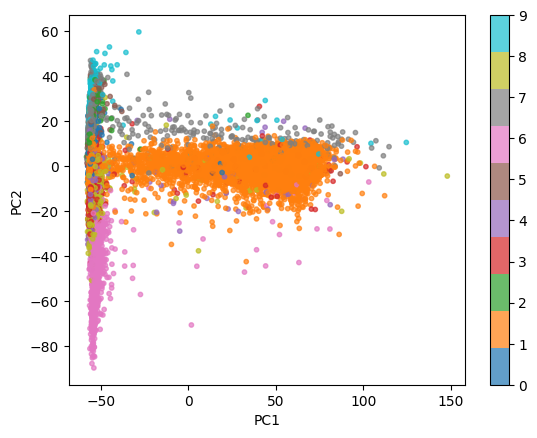

In [41]:
# pca
from sklearn.decomposition import PCA

pca = PCA(n_components=43)
X_full_pca = pca.fit_transform(X_full)

plt.scatter(X_full_pca[:, 0], X_full_pca[:, 1], c=y_full, cmap="tab10", alpha=0.7, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

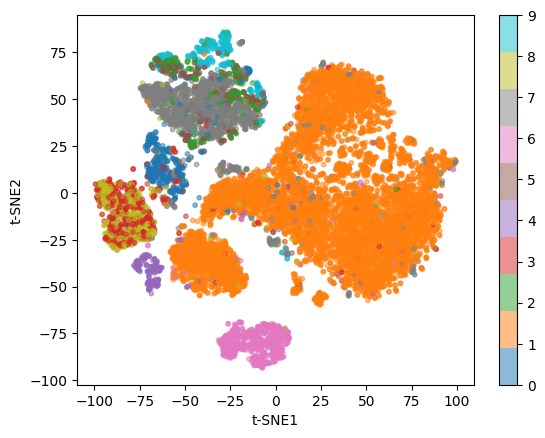

In [ ]:
# tsne
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=20, init="pca", early_exaggeration=5)
X_full_tsne = tsne.fit_transform(X_full)
plt.scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=y_full, cmap="tab10", alpha=0.5, s=10)
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.colorbar()
plt.show()

T-SNE hyperparameters (determined visually):

- `perplexity=20`
- `init="pca"`
- `early_exaggeration=5`

c:\Users\jjzha\Documents\Northwestern\Year3_2526\STAT_362\stat362\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


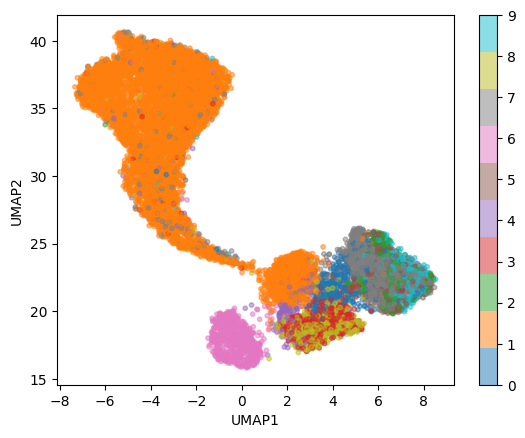

In [71]:
# umap
import umap

umap1 = umap.UMAP(n_components=2, random_state=42, n_neighbors=40, min_dist=0.6, metric="manhattan")
X_full_umap = umap1.fit_transform(X_full)
plt.scatter(X_full_umap[:, 0], X_full_umap[:, 1], c=y_full, cmap="tab10", alpha=0.5, s=10)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar()
plt.show()

UMAP hyperparameters (determined visually):

- `n_neighbors=40`
- `min_dist=0.6`
- `metric="manhattan"`

## Task 4: Evaluating Clustering Algorithms on 2D Embeddings (30 points)

Clustering algorithms often struggle with the curse of dimensionality, which can lead to poor performance on high-dimensional data.  
To address this, use the **2-dimensional representation** obtained from **t-SNE** in Task 2 (`n_components = 2`, `perplexity = 25`).

Apply **three different clustering algorithms** to the 2D data and evaluate their effectiveness.  
For each algorithm, report the following:

- **Visualization** of the clustering result (dimension = 2)
- **Number of clusters**
- **Number of outliers** (`cluster_labels == -1`, if applicable)
- **Completeness score** and **Homogeneity score**  
  (refer to scikit-learn documentation for how to compute these metrics given ground-truth labels)

**Note:**  
Since clustering is unsupervised, use the entire dataset when tuning hyperparameters (no train-test split needed).


In [19]:
from sklearn.metrics import homogeneity_score, completeness_score

In [8]:
# tsne representation
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=25)
X_full_tsne = tsne.fit_transform(X_full)

K-Means Number of clusters: 10
K-Means Homogeneity Score: 0.580
K-Means Completeness Score: 0.371


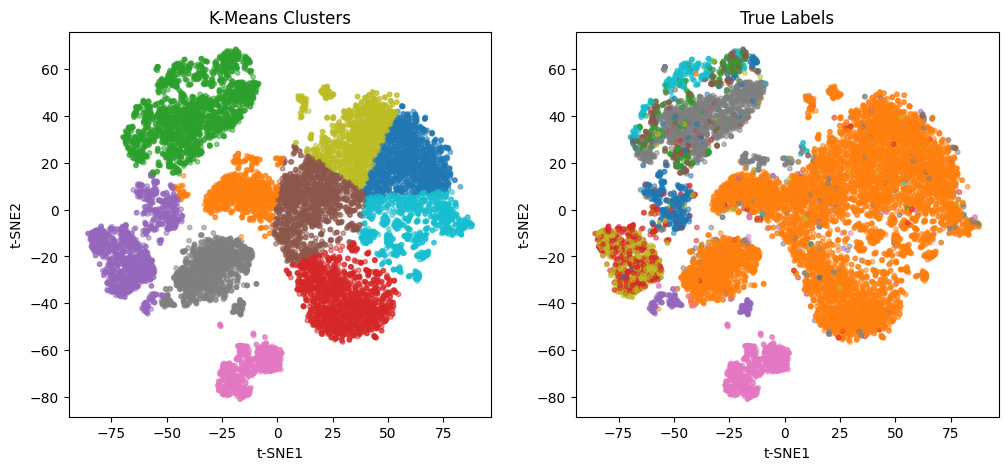

In [46]:
# kmeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42).fit(X_full_tsne)
kmeans_labels = kmeans.labels_

# homoegeneity and completeness score
kmeans_homogeneity = homogeneity_score(y_full, kmeans_labels)
kmeans_completeness = completeness_score(y_full, kmeans_labels)
print(f"K-Means Number of clusters: {10}")
print(f"K-Means Homogeneity Score: {kmeans_homogeneity:.3f}")
print(f"K-Means Completeness Score: {kmeans_completeness:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=kmeans_labels, cmap="tab10", alpha=0.5, s=10)
axs[1].scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=y_full, cmap="tab10", alpha=0.5, s=10)

axs[0].set_title("K-Means Clusters")
axs[0].set_xlabel("t-SNE1")
axs[0].set_ylabel("t-SNE2")
axs[1].set_title("True Labels")
axs[1].set_xlabel("t-SNE1")
axs[1].set_ylabel("t-SNE2")
plt.show()

DBSCAN Number of clusters: 213
DBSCAN Number of outliers: 10478
DBSCAN Homogeneity Score: 0.132
DBSCAN Completeness Score: 0.211


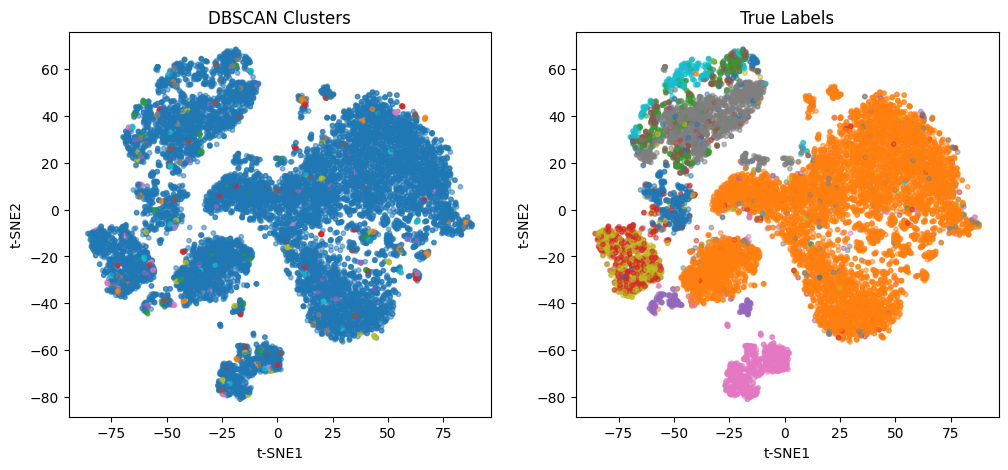

In [47]:
# dbscan
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X_full_tsne)
dbscan_labels = dbscan.labels_
dbscan_n_clusters = len(set(dbscan_labels))
dbscan_n_outliers = sum(dbscan_labels == -1)

# homoegeneity and completeness score
dbscan_homogeneity = homogeneity_score(y_full, dbscan_labels)
dbscan_completeness = completeness_score(y_full, dbscan_labels)
print(f"DBSCAN Number of clusters: {dbscan_n_clusters}")
print(f"DBSCAN Number of outliers: {dbscan_n_outliers}")
print(f"DBSCAN Homogeneity Score: {dbscan_homogeneity:.3f}")
print(f"DBSCAN Completeness Score: {dbscan_completeness:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=dbscan_labels, cmap="tab10", alpha=0.5, s=10)
axs[1].scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=y_full, cmap="tab10", alpha=0.5, s=10)

axs[0].set_title("DBSCAN Clusters")
axs[0].set_xlabel("t-SNE1")
axs[0].set_ylabel("t-SNE2")
axs[1].set_title("True Labels")
axs[1].set_xlabel("t-SNE1")
axs[1].set_ylabel("t-SNE2")
plt.show()

HDBSCAN Number of clusters: 12
HDBSCAN Number of outliers: 170
HDBSCAN Homogeneity Score: 0.636
HDBSCAN Completeness Score: 0.628


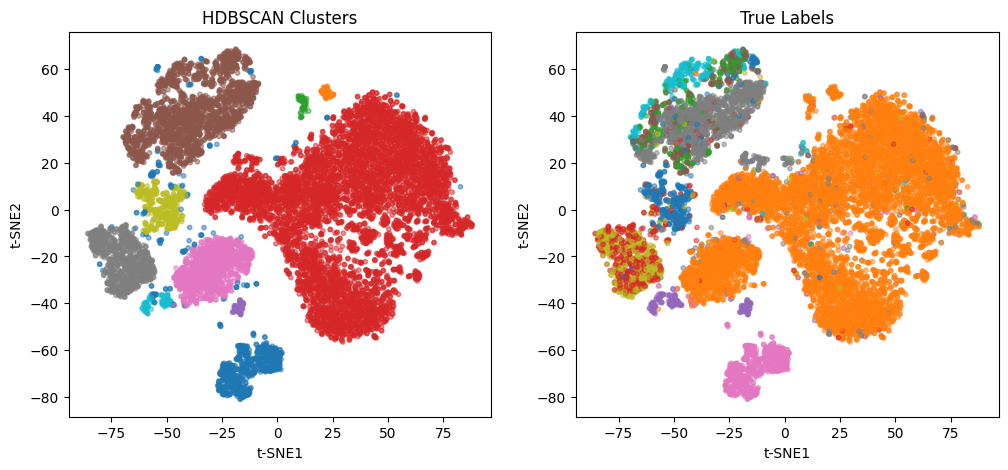

In [48]:
# hdbscan
from sklearn.cluster import HDBSCAN

hdbscan = HDBSCAN(min_cluster_size=25).fit(X_full_tsne)
hdbscan_labels = hdbscan.labels_
hdbscan_n_clusters = len(set(hdbscan_labels))
hdbscan_n_outliers = sum(hdbscan_labels == -1)

# homoegeneity and completeness score
hdbscan_homogeneity = homogeneity_score(y_full, hdbscan_labels)
hdbscan_completeness = completeness_score(y_full, hdbscan_labels)
print(f"HDBSCAN Number of clusters: {hdbscan_n_clusters}")
print(f"HDBSCAN Number of outliers: {hdbscan_n_outliers}")
print(f"HDBSCAN Homogeneity Score: {hdbscan_homogeneity:.3f}")
print(f"HDBSCAN Completeness Score: {hdbscan_completeness:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=hdbscan_labels, cmap="tab10", alpha=0.5, s=10)
axs[1].scatter(X_full_tsne[:, 0], X_full_tsne[:, 1], c=y_full, cmap="tab10", alpha=0.5, s=10)

axs[0].set_title("HDBSCAN Clusters")
axs[0].set_xlabel("t-SNE1")
axs[0].set_ylabel("t-SNE2")
axs[1].set_title("True Labels")
axs[1].set_xlabel("t-SNE1")
axs[1].set_ylabel("t-SNE2")
plt.show()

## Task 5: Summary of Best Results and Reflection (10 points)

Summarize the best results you obtained from each of the previous tasks and explain what you learned from this assignment.


Task 1:

- The logistic regression model was the best classifier model according to macro F1 score, which was somewhat surprising given that gradient boosted methods typically outperform linear models in prediction tasks.
- Among the gradient boosting methods, XGBoost ran the fastest by far while still performing comparably to LightGBM and CatBoost.

Task 2:

- PCA is a more effective dimensionality reduction method than UMAP for this dataset, and the classification performance was much higher across the board.
- The best performance for PCA was achieved at 400 components, but 43 components also gave comparable results while using far fewer components.

Task 3:

- The hyperparameters for t-SNE and UMAP are very important in developing informative visualizations.
- Some of the clusters are clearly separated in all visualizations, while others have more overlap.

Task 4:

- HDBSCAN performs far better than both DBSCAN and KMeans on this dataset according to the homogeneity and completeness scores.
- The uniformity of clusters in KMeans fails to capture some of the true groupings, and DBSCAN does not make any significant clusterings.